# Implementing a simple two layers neural network
In this exercise we will develop a two neural net1work with fully-connected layers to perform classification, and test it out on the MNIST dataset.


In [1]:
"""
-----------------------------------------------------------------------------
A simple two layers neural network for handwritten digit classification (MNIST)
-----------------------------------------------------------------------------
AUTHOR: Soumitra Samanta (soumitra.samanta@gm.rkmvu.ac.in)
-----------------------------------------------------------------------------
"""

import gzip
import numpy as np
import matplotlib.pyplot as plt
import copy
import tensorflow

from tensorflow import keras

from first_nn_exc import *

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2


2026-02-12 19:58:49.567815: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-12 19:58:49.646628: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-12 19:58:50.882892: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Read MNIST data:
You can download the data from [here](https://www.kaggle.com/datasets/hojjatk/mnist-dataset). There are many [way](https://stackoverflow.com/questions/40427435/extract-images-from-idx3-ubyte-file-or-gzip-via-python) you can read the MNIST data. Here is a [way](https://stackoverflow.com/a/62781370) to read all the information.

In [2]:
(x_train,y_train),(x_test,y_test) = keras.datasets.mnist.load_data()

Train data (X) size: (60000, 28, 28), and labels (Y) size: (60000,)
Test data (X) size: (10000, 28, 28), and labels (Y) size: (10000,)


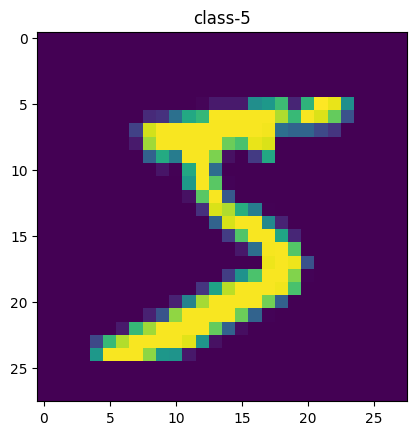

In [3]:
# def read_images(filename):
#     """Read MNIST images"""
    
#     with gzip.open(filename, 'r') as f:
#         # first 4 bytes is a magic number
#         magic_number = int.from_bytes(f.read(4), 'big')
#         # second 4 bytes is the number of images
#         image_count = int.from_bytes(f.read(4), 'big')
#         # third 4 bytes is the row count
#         row_count = int.from_bytes(f.read(4), 'big')
#         # fourth 4 bytes is the column count
#         column_count = int.from_bytes(f.read(4), 'big')
#         # rest is the image pixel data, each pixel is stored as an unsigned byte
#         # pixel values are 0 to 255
#         image_data = f.read()
#         images = np.frombuffer(image_data, dtype=np.uint8).reshape((image_count, row_count, column_count))
        
#     return images

# def read_labels(filename):
#     """Read MNIST labels"""
    
#     with gzip.open(filename, 'r') as f:
#         # first 4 bytes is a magic number
#         magic_number = int.from_bytes(f.read(4), 'big')
#         # second 4 bytes is the number of labels
#         label_count = int.from_bytes(f.read(4), 'big')
#         # rest is the label data, each label is stored as unsigned byte
#         # label values are 0 to 9
#         label_data = f.read()
#         labels = np.frombuffer(label_data, dtype=np.uint8)
        
#     return labels


# dataset_path = '/Users/soumitra/Library/CloudStorage/OneDrive-Personal/Documents/SS_PERSONAL/SS_TEACHING/RKMVERI/data_experiment/mnist/'

# train_image_filename = ''.join([dataset_path, 'train-images-idx3-ubyte.gz'])
# train_label_filename = ''.join([dataset_path, 'train-labels-idx1-ubyte.gz'])

# test_image_filename = ''.join([dataset_path, 't10k-images-idx3-ubyte.gz'])
# test_label_filename = ''.join([dataset_path, 't10k-labels-idx1-ubyte.gz'])

# train_images = read_images(train_image_filename)
# train_labels = read_labels(train_label_filename)

# print('Train data (X) size: {}, and labels (Y) size: {}' .format(train_images.shape, train_labels.shape))

# test_images = read_images(test_image_filename)
# test_labels = read_labels(test_label_filename)

# print('Test data (X) size: {}, and labels (Y) size: {}' .format(test_images.shape, test_labels.shape))



# rand_ids = np.random.choice(train_images.shape[0])
# plt.imshow(train_images[rand_ids, :, :], cmap='gray')
# plt.title('class-'+str(train_labels[rand_ids]))
# plt.show()



train_images = x_train
train_labels = y_train

print('Train data (X) size: {}, and labels (Y) size: {}' .format(train_images.shape, train_labels.shape))

test_images = x_test
test_labels = y_test

print('Test data (X) size: {}, and labels (Y) size: {}' .format(test_images.shape, test_labels.shape))



plt.imshow(x_train[0])
plt.title('class-'+str(y_train[0]))
plt.show()

# CROSS-CHECK: Create a validation data from training data (10%) and transform the data in $\mathbf{R}^d$.

In [10]:
val_data_ration = 0.1
class_ids = list(set(train_labels))
val_ids = []
for cl in class_ids:
    temp_val_index = np.where(train_labels==cl)
    val_ids.extend(list(np.random.permutation(temp_val_index[0])[:round(temp_val_index[0].shape[0]*val_data_ration)]))
# print(val_ids)     
val_images = train_images[val_ids, :, :]  
val_labels = train_labels[val_ids]  
print('Val data (X) size: {}, and labels (Y) size: {}' .format(val_images.shape, val_labels.shape))

train_ids = [i for i in range(train_labels.shape[0]) if i not in val_labels]
revised_train_images = train_images[train_ids, :, :]  
revised_train_labels = train_labels[train_ids]  
 
X_train = revised_train_images.reshape(revised_train_images.shape[0], -1)
Y_train = revised_train_labels.reshape(-1)
X_val = val_images.reshape(val_images.shape[0], -1)
Y_val = val_labels.reshape(-1)
X_test = test_images.reshape(test_images.shape[0], -1)
Y_test = test_labels.reshape(-1)

print('After reshape\n')
print('Train data (X) size: {}, and labels (Y) size: {}' .format(X_train.shape, Y_train.shape))
print('Val data (X) size: {}, and labels (Y) size: {}' .format(X_val.shape, Y_val.shape))
print('Test data (X) size: {}, and labels (Y) size: {}' .format(X_test.shape, Y_test.shape))                       

Val data (X) size: (5999, 28, 28), and labels (Y) size: (5999,)
After reshape

Train data (X) size: (59990, 784), and labels (Y) size: (59990,)
Val data (X) size: (5999, 784), and labels (Y) size: (5999,)
Test data (X) size: (10000, 784), and labels (Y) size: (10000,)


# Train a network
To train our network we will use Stochastic Gradient Decent (SGD).

In [ ]:
data_dimension = X_train.shape[1]
num_hidden_nodes = 50
num_classes = 10
net = FirstNN(data_dimension, num_hidden_nodes, num_classes)

# Train the network
stats = net.train(X_train, Y_train, X_val, Y_val, 
                  num_iters=10000,
                  num_epoch=30,
                  batch_size=200, 
                  learning_rate=1e-2, 
                  verbose=True
                 )

Training epoch 1/(30)
----------------------------------------------------------------------


iteration: 299 / (300), loss: 1.402472: 100%|██████████| 300/300 [00:00<00:00, 359.27it/s]


epoch: 1 / (30), loss: 1.817307, train acc: 77.64, val acc: 77.08
Training epoch 2/(30)
----------------------------------------------------------------------


iteration: 299 / (300), loss: 0.923929: 100%|██████████| 300/300 [00:00<00:00, 312.90it/s]


epoch: 2 / (30), loss: 1.196088, train acc: 85.96, val acc: 85.30
Training epoch 3/(30)
----------------------------------------------------------------------


...

epoch: 28 / (30), loss: 0.215599, train acc: 94.80, val acc: 94.37
Training epoch 29/(30)
----------------------------------------------------------------------


iteration: 299 / (300), loss: 0.230417: 100%|██████████| 300/300 [00:00<00:00, 305.25it/s]


epoch: 29 / (30), loss: 0.214234, train acc: 94.89, val acc: 94.53
Training epoch 30/(30)
----------------------------------------------------------------------


iteration: 299 / (300), loss: 0.173983: 100%|██████████| 300/300 [00:01<00:00, 299.41it/s]


epoch: 30 / (30), loss: 0.209404, train acc: 94.68, val acc: 94.75


In [6]:
# Predict on the train set
Y_train_pred = net.predict(X_train, best_param=True)
train_acc = 100*(Y_train_pred == Y_train).mean()
print('Train accuracy: {:.2f}' .format(train_acc))

# Predict on the validation set
Y_val_pred = net.predict(X_val, best_param=True)
val_acc = 100*(Y_val_pred == Y_val).mean()
print('Validation accuracy: {:.2f}' .format(val_acc))

# Predict on the test set
Y_test_pred = net.predict(X_test, best_param=True)
test_acc = 100*(Y_test_pred == Y_test).mean()
print('Test accuracy: {:.2f}' .format(test_acc))

Train accuracy: 94.68
Validation accuracy: 94.75
Test accuracy: 93.95


# Plot the loss.

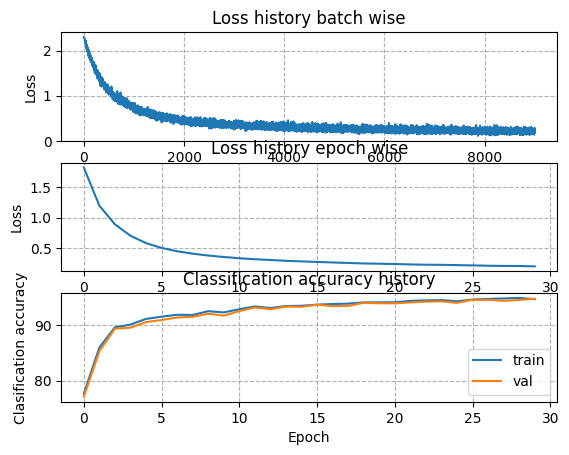

In [9]:
# Plot the loss function and train / validation accuracies
plt.subplot(3, 1, 1)
plt.plot(stats['loss_history_batch'])
plt.title('Loss history batch wise')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(linestyle='--')

plt.subplot(3, 1, 2)
plt.plot(stats['loss_history_epoch'])
plt.title('Loss history epoch wise')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(linestyle='--')

plt.subplot(3, 1, 3)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Clasification accuracy')
plt.grid(linestyle='--')
plt.legend()
plt.show()

# TODO: Tune your hyperparameters:
    - Learning rate:
    - Number of nodes in hidden layer:


In [ ]:
best_net = None # store the best model into this 

#################################################################################
# TODO: Tune hyperparameters using the validation set. Store your best trained  #
# model in best_net.                                                            #
#################################################################################
results = {}
best_val = 0
learning_rates = [1e-3, 5e-3, 7e-3, 1e-2, 5e-2, 1e-1]
num_hidden_nodes = [20,30, 50, 60, 70, 100]
num_classes = 10
num_iters = 5000
num_epoch = 30
batch_size = 256
data_dimension = X_train.shape[1]
train_accu = []
validation_accu = []
test_accu = []
record = {
    'learning_rate': [],
    'num_hidden_node' : [],
    'train_accu' : [],
    'test_accu': [],
    'val_accu' : []
}
for i in range(len(learning_rates)):
    for j in range(len(num_hidden_nodes)):
        print("=="*50)
        print(f'Learning_rates : {learning_rates[i]} , num_hidded_node: {num_hidden_nodes[j]} ')
        net1 = FirstNN(data_dimension, num_hidden_nodes[i], num_classes)
        net1.train(X_train, Y_train, X_val, Y_val, 
                    num_iters=5000,
                    num_epoch=30,
                    batch_size=256, 
                    learning_rate= learning_rates[j], 
                    verbose=True
                    )
        Y_train_pred = net1.predict(X_train, best_param=True)
        train_acc = 100*(Y_train_pred == Y_train).mean()
        record['learning_rate'].append(learning_rates[j])
        record['num_hidden_node'].append(num_hidden_nodes[i])
        record['train_accu'].append(train_acc)
        # print('Train accuracy: {:.2f}' .format(train_acc))

        # Predict on the validation set
        Y_val_pred = net1.predict(X_val, best_param=True)
        val_acc = 100*(Y_val_pred == Y_val).mean()
        record['val_accu'].append(val_acc)
        # print('Validation accuracy: {:.2f}' .format(val_acc))

        # Predict on the test set
        Y_test_pred = net1.predict(X_test, best_param=True)
        test_acc = 100*(Y_test_pred == Y_test).mean()
        # print('Test accuracy: {:.2f}' .format(test_acc))
        record['test_accu'].append(test_acc)
    
    


# Print best results.
# print('Best validation accuracy achieved during cross-validation: {:.2f} for #hdnn: {}, lr: {}' .format(best_val, best_net.best_params['W1'].shape[1], best_net.learning_rate))
#################################################################################
#                               END OF YOUR CODE                                #
#################################################################################

Learning_rates : 0.001 , num_hidded_node: 20 
Training epoch 1/(10)
----------------------------------------------------------------------


iteration: 234 / (235), loss: 2.261973: 100%|██████████| 235/235 [00:02<00:00, 102.30it/s]


epoch: 1 / (10), loss: 2.293992, train acc: 16.81, val acc: 16.60
Training epoch 2/(10)
----------------------------------------------------------------------


iteration: 234 / (235), loss: 2.211131: 100%|██████████| 235/235 [00:01<00:00, 151.61it/s]


epoch: 2 / (10), loss: 2.240589, train acc: 25.46, val acc: 25.35
Training epoch 3/(10)
----------------------------------------------------------------------


...

epoch: 8 / (10), loss: 0.284637, train acc: 91.52, val acc: 91.47
Training epoch 9/(10)
----------------------------------------------------------------------


iteration: 234 / (235), loss: 0.297540: 100%|██████████| 235/235 [00:01<00:00, 149.65it/s]


epoch: 9 / (10), loss: 0.281966, train acc: 92.04, val acc: 91.97
Training epoch 10/(10)
----------------------------------------------------------------------


iteration: 234 / (235), loss: 0.134548: 100%|██████████| 235/235 [00:01<00:00, 138.20it/s]


epoch: 10 / (10), loss: 0.279110, train acc: 92.16, val acc: 92.08


In [32]:
import pandas as pd

In [33]:
d = pd.DataFrame(record)

In [49]:
m = max(d['val_accu'])
best_val = d[d['val_accu'] == m]

In [50]:
best_val

,learning_rate,num_hidden_node,train_accu,test_accu,val_accu
34,0.05,100,94.112352,93.71,93.848975


# Test on best model

In [ ]:
# Predict on the train set
Y_train_pred = best_net.predict(X_train, best_param=True)
train_acc = 100*(Y_train_pred == Y_train).mean()
print('Train accuracy: {:.2f}' .format(train_acc))

# Predict on the validation set
Y_val_pred = best_net.predict(X_val, best_param=True)
val_acc = 100*(Y_val_pred == Y_val).mean()
print('Validation accuracy: {:.2f}' .format(val_acc))

# Predict on the test set
Y_test_pred = best_net.predict(X_test, best_param=True)
test_acc = 100*(Y_test_pred == Y_test).mean()
print('Test accuracy: {:.2f}' .format(test_acc))